In [1]:
"""Simple node objects backed by the shared orbital network model."""

from pathlib import Path
import sys

repo_root = next(
    parent for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "mpex").is_dir()
)
network_python = repo_root / "network" / "python"
for path in (repo_root, network_python):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from network_graph import RELAYS, RELAY_PERIOD, SETTLEMENTS, System

try:
    from relay_placement import BRIEF_ANGLES
except (ImportError, ModuleNotFoundError):
    BRIEF_ANGLES = (45.0, 135.0)

from mpex.constants import NODE_IDS


class Node:
    """A named network node whose position is evaluated at a given time."""

    def __init__(self, name, system=None):
        if name not in NODE_IDS:
            raise ValueError(f"unknown node {name!r}")
        self.name = name
        self.node_id = NODE_IDS[name]
        self.system = system or System()

    def position(self, t_days=0.0):
        """Return the node's ``(x, y, z)`` position in AU."""
        return self.system.position(self.name, t_days)


class sender(Node):
    """A settlement node that can originate a transmission."""


class exchange(Node):
    """A settlement node representing a local exchange."""


class relay(Node):
    """A relay node in the backbone network."""


def create_nodes(system=None, t_days=0.0):
    """Create the settlement and relay nodes with their current positions.

    ``BRIEF_ANGLES`` is kept on the returned relay nodes as the placement
    reference used by the relay-placement study; actual coordinates come from
    ``network_graph.System`` so both models use the same orbital data.
    """
    system = system or System()
    nodes = {}
    for name in SETTLEMENTS:
        nodes[name] = sender(name, system)
        nodes[f"{name} exchange"] = exchange(name, system)
    for name, phase in zip(RELAYS, BRIEF_ANGLES):
        node = relay(name, system)
        node.placement_angle_deg = phase
        nodes[name] = node
    for node in nodes.values():
        node.current_position = node.position(t_days)
    return nodes

In [40]:
def compute_route_probability_matrices(system, times_days, relay_attempts=2):
    """Return period-average route success probabilities with visibility checks."""
    route_probabilities = {
        "direct": np.zeros((len(SETTLEMENTS), len(SETTLEMENTS))),
        **{
            f"via {relay}": np.zeros((len(SETTLEMENTS), len(SETTLEMENTS)))
            for relay in RELAYS
        },
    }

    for t_days in times_days:
        for source_index, source in enumerate(SETTLEMENTS):
            for target_index, target in enumerate(SETTLEMENTS):
                if source == target:
                    route_probabilities["direct"][source_index, target_index] += 1.0
                    for relay in RELAYS:
                        route_probabilities[f"via {relay}"][source_index, target_index] += 1.0
                    continue

                direct_hop = system.direct(source, target, t_days)
                direct_probability = (
                    1.0 - direct_hop["loss"]
                    if direct_hop["status"] == "open"
                    else 0.0
                )
                route_probabilities["direct"][source_index, target_index] += direct_probability

                for relay in RELAYS:
                    route = system.evaluate_route([source, relay, target], t_days)
                    route_loss = 1.0 - route["p_first_try"]
                    route_probability = (
                        1.0 - route_loss ** relay_attempts
                        if route["open"]
                        else 0.0
                    )
                    route_probabilities[f"via {relay}"][source_index, target_index] += route_probability

    return {
        route: pd.DataFrame(
            values / len(times_days),
            index=SETTLEMENTS,
            columns=SETTLEMENTS,
        )
        for route, values in route_probabilities.items()
    }

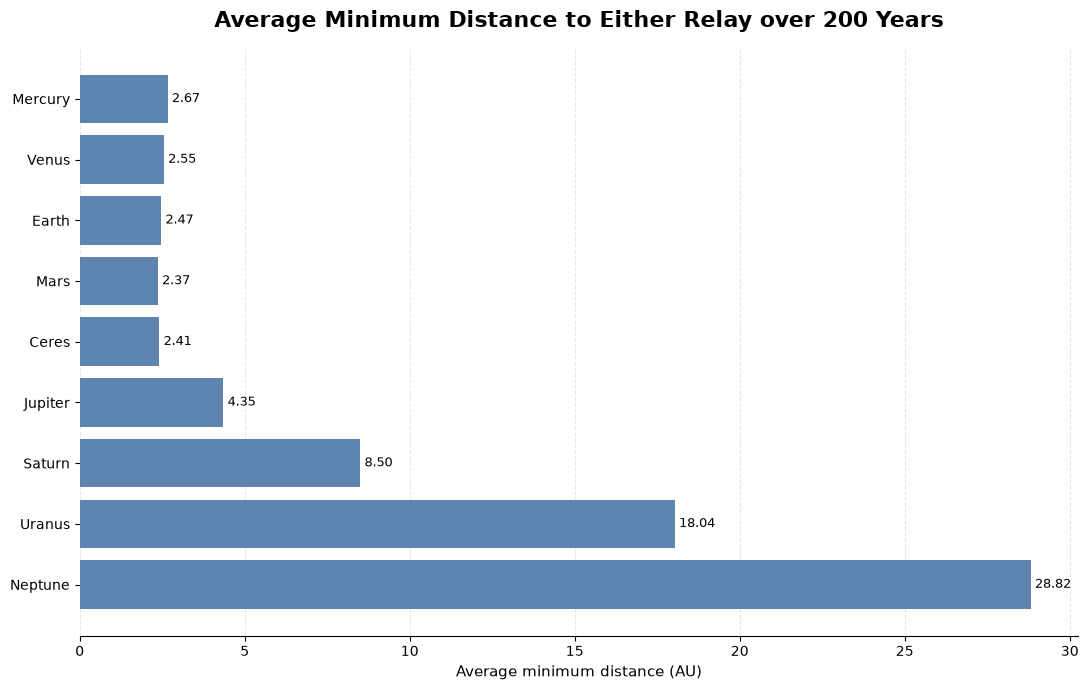

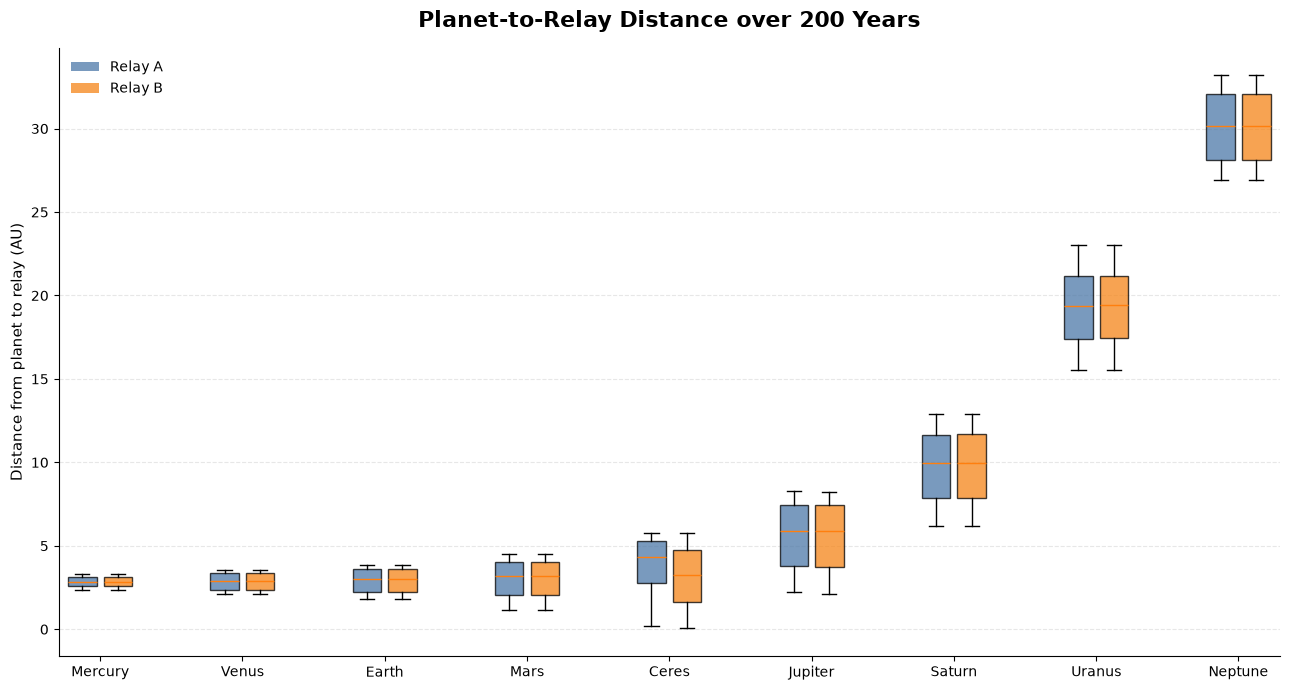

In [34]:
import numpy as np

import matplotlib.pyplot as plt

nodes = create_nodes()
ANALYSIS_PERIOD_YEARS = 200
analysis_period_days = ANALYSIS_PERIOD_YEARS * 365.25
sample_count = 4096
times_days = np.linspace(0.0, analysis_period_days, sample_count, endpoint=False)
planet_positions = np.asarray([
    [nodes[planet].position(t_days) for planet in SETTLEMENTS]
    for t_days in times_days
])
relay_positions = np.asarray([
    [nodes[relay].position(t_days) for relay in RELAYS]
    for t_days in times_days
])

distance_by_relay = np.linalg.norm(
    planet_positions[:, :, np.newaxis, :] - relay_positions[:, np.newaxis, :, :],
    axis=-1,
)
minimum_distances = distance_by_relay.min(axis=2)
average_minimum_distance = minimum_distances.mean(axis=0)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    SETTLEMENTS,
    average_minimum_distance,
    color="#4C78A8",
    alpha=0.9,
)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Average minimum distance (AU)", fontsize=11)
ax.set_title(
    f"Average Minimum Distance to Either Relay over {ANALYSIS_PERIOD_YEARS} Years",
    fontsize=16,
    weight="bold",
    pad=15,
)
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 7))
box_data = []
box_positions = []
box_colors = []
planet_positions_on_axis = []
for planet_index, planet in enumerate(SETTLEMENTS):
    center = planet_index * 3 + 1.5
    planet_positions_on_axis.append(center)
    for relay_index in range(len(RELAYS)):
        box_data.append(distance_by_relay[:, planet_index, relay_index])
        box_positions.append(center + (relay_index - 0.5) * 0.75)
        box_colors.append(["#4C78A8", "#F58518"][relay_index])

boxplot = ax.boxplot(
    box_data,
    positions=box_positions,
    widths=0.6,
    patch_artist=True,
    showfliers=False,
)
for patch, color in zip(boxplot["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticks(planet_positions_on_axis)
ax.set_xticklabels(SETTLEMENTS)
ax.set_ylabel("Distance from planet to relay (AU)", fontsize=11)
ax.set_title(
    f"Planet-to-Relay Distance over {ANALYSIS_PERIOD_YEARS} Years",
    fontsize=16,
    weight="bold",
    pad=15,
)
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#4C78A8", alpha=0.75, label="Relay A"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#F58518", alpha=0.75, label="Relay B"),
]
ax.legend(handles=legend_handles, frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [35]:
import pandas as pd

boxplot_rows = []
for planet_index, planet in enumerate(SETTLEMENTS):
    for relay_index, relay_name in enumerate(RELAYS):
        distances = distance_by_relay[:, planet_index, relay_index]
        boxplot_rows.append({
            "planet": planet,
            "reference": relay_name,
            "minimum_au": np.min(distances),
            "q1_au": np.percentile(distances, 25),
            "median_au": np.median(distances),
            "mean_au": np.mean(distances),
            "q3_au": np.percentile(distances, 75),
            "maximum_au": np.max(distances),
        })

boxplot_dataframe = pd.DataFrame(boxplot_rows)
print(boxplot_dataframe.to_string(index=False, float_format="{:.4f}".format))
boxplot_dataframe

 planet reference  minimum_au   q1_au  median_au  mean_au   q3_au  maximum_au
Mercury   Relay A      2.3644  2.5753     2.8558   2.8428  3.1104      3.2928
Mercury   Relay B      2.3644  2.5718     2.8557   2.8428  3.1087      3.2929
  Venus   Relay A      2.1014  2.3731     2.9166   2.8749  3.3791      3.5561
  Venus   Relay B      2.1011  2.3768     2.9183   2.8751  3.3799      3.5561
  Earth   Relay A      1.8123  2.2344     2.9965   2.9170  3.6050      3.8448
  Earth   Relay B      1.8121  2.2381     2.9999   2.9179  3.6055      3.8448
   Mars   Relay A      1.1648  2.0680     3.2155   3.0404  4.0440      4.4932
   Mars   Relay B      1.1654  2.0438     3.2052   3.0340  4.0456      4.4935
  Ceres   Relay A      0.1872  2.7496     4.3160   3.8798  5.2861      5.7927
  Ceres   Relay B      0.0566  1.6050     3.2670   3.1601  4.7359      5.7910
Jupiter   Relay A      2.2170  3.7860     5.8904   5.5931  7.4605      8.2813
Jupiter   Relay B      2.1261  3.7507     5.8969   5.5835  7.458

,planet,reference,minimum_au,q1_au,median_au,mean_au,q3_au,maximum_au
0,Mercury,Relay A,2.364387,2.575277,2.855827,2.842849,3.110425,3.292810
1,Mercury,Relay B,2.364403,2.571840,2.855696,2.842781,3.108739,3.292866
2,Venus,Relay A,2.101369,2.373102,2.916554,2.874913,3.379082,3.556078
3,Venus,Relay B,2.101095,2.376794,2.918277,2.875075,3.379871,3.556061
4,Earth,Relay A,1.812330,2.234374,2.996525,2.916965,3.605003,3.844831
5,Earth,Relay B,1.812073,2.238054,2.999856,2.917855,3.605464,3.844751
6,Mars,Relay A,1.164808,2.067981,3.215487,3.040395,4.044039,4.493216
7,Mars,Relay B,1.165443,2.043763,3.205206,3.034040,4.045649,4.493510
8,Ceres,Relay A,0.187211,2.749572,4.316011,3.879795,5.286091,5.792718
9,Ceres,Relay B,0.056598,1.605040,3.267025,3.160128,4.735915,5.791033


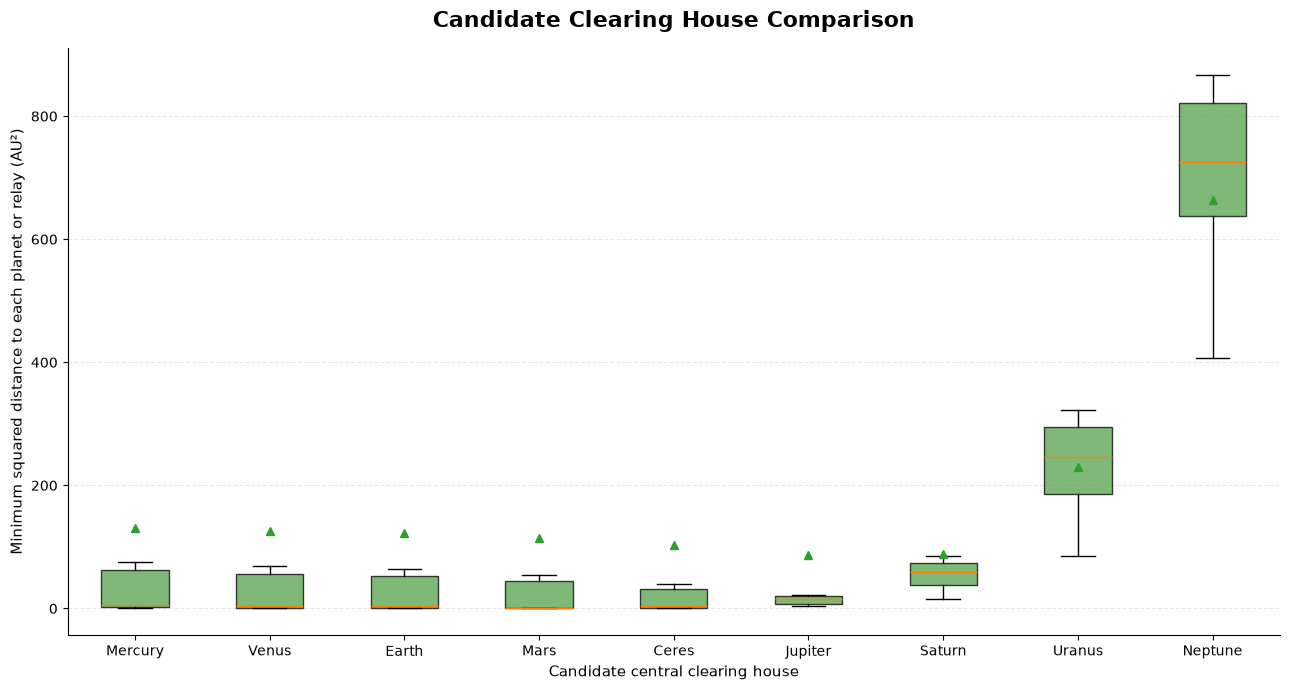

clearing_house target_node  minimum_squared_distance_au2
       Mercury       Venus                        0.0684
       Mercury       Earth                        0.3013
       Mercury        Mars                        0.9333
       Mercury       Ceres                        4.7222
       Mercury     Jupiter                       21.1598
       Mercury      Saturn                       75.8079
       Mercury      Uranus                      322.9057
       Mercury     Neptune                      867.6663
       Mercury     Relay A                        5.5903
       Mercury     Relay B                        5.5904
         Venus     Mercury                        0.0684
         Venus       Earth                        0.0697
         Venus        Mars                        0.4279
         Venus       Ceres                        3.3636
         Venus     Jupiter                       17.8944
         Venus      Saturn                       68.8126
         Venus      Uranus     

,clearing_house,target_node,minimum_squared_distance_au2
0,Mercury,Venus,0.068400
1,Mercury,Earth,0.301261
2,Mercury,Mars,0.933347
3,Mercury,Ceres,4.722177
4,Mercury,Jupiter,21.159768
...,...,...,...
85,Neptune,Jupiter,609.036837
86,Neptune,Saturn,407.502148
87,Neptune,Uranus,102.955348
88,Neptune,Relay A,725.945131


In [36]:
node_names = list(SETTLEMENTS) + list(RELAYS)
all_node_positions = np.concatenate([planet_positions, relay_positions], axis=1)
clearing_house_box_data = []
clearing_house_rows = []

for clearing_house_index, clearing_house in enumerate(SETTLEMENTS):
    clearing_house_position = planet_positions[:, clearing_house_index, :]
    squared_distances = np.sum(
        (all_node_positions - clearing_house_position[:, np.newaxis, :]) ** 2,
        axis=-1,
    )
    squared_distances[:, clearing_house_index] = np.inf
    minimum_squared_distance = squared_distances.min(axis=0)
    minimum_squared_distance = np.delete(minimum_squared_distance, clearing_house_index)
    target_names = [
        name for index, name in enumerate(node_names)
        if index != clearing_house_index
    ]

    clearing_house_box_data.append(minimum_squared_distance)
    clearing_house_rows.extend(
        {
            "clearing_house": clearing_house,
            "target_node": target,
            "minimum_squared_distance_au2": distance,
        }
        for target, distance in zip(target_names, minimum_squared_distance)
    )

fig, ax = plt.subplots(figsize=(13, 7))
clearing_house_boxplot = ax.boxplot(
    clearing_house_box_data,
    tick_labels=SETTLEMENTS,
    patch_artist=True,
    showfliers=False,
    showmeans=True,
)
for patch in clearing_house_boxplot["boxes"]:
    patch.set_facecolor("#54A24B")
    patch.set_alpha(0.75)

ax.set_xlabel("Candidate central clearing house", fontsize=11)
ax.set_ylabel("Minimum squared distance to each planet or relay (AU²)", fontsize=11)
ax.set_title(
    "Candidate Clearing House Comparison",
    fontsize=16,
    weight="bold",
    pad=15,
)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

clearing_house_dataframe = pd.DataFrame(clearing_house_rows)
print(clearing_house_dataframe.to_string(index=False, float_format="{:.4f}".format))
clearing_house_dataframe

# Probability Matrix

In [41]:
RELAY_ATTEMPTS = 2

probability_matrices = compute_route_probability_matrices(
    nodes[SETTLEMENTS[0]].system,
    times_days,
    relay_attempts=RELAY_ATTEMPTS,
)

route_names = list(probability_matrices)
route_arrays = np.stack([
    probability_matrices[route_name].to_numpy()
    for route_name in route_names
])
best_route_indices = route_arrays.argmax(axis=0)
probability_matrix = pd.DataFrame(
    route_arrays.max(axis=0),
    index=SETTLEMENTS,
    columns=SETTLEMENTS,
)
selected_route_matrix = pd.DataFrame(
    np.vectorize(route_names.__getitem__)(best_route_indices),
    index=SETTLEMENTS,
    columns=SETTLEMENTS,
)

for route_name, matrix in probability_matrices.items():
    print(f"\\nAverage route success probability with blockage checks: {route_name}")
    print(matrix.to_string(float_format="{:.4f}".format))

print("\\nHighest-probability route for each source and clearing-house pair:")
print(probability_matrix.to_string(float_format="{:.4f}".format))
selected_route_matrix

\nAverage route success probability with blockage checks: direct
         Mercury  Venus  Earth   Mars  Ceres  Jupiter  Saturn  Uranus  Neptune
Mercury   1.0000 0.8249 0.8199 0.7942 0.7282   0.6084  0.4305  0.1984   0.0834
Venus     0.8251 1.0000 0.8485 0.8255 0.7629   0.6276  0.4452  0.2067   0.0869
Earth     0.8199 0.8485 1.0000 0.8302 0.7832   0.6343  0.4514  0.2093   0.0880
Mars      0.7940 0.8255 0.8302 1.0000 0.7808   0.6414  0.4562  0.2120   0.0890
Ceres     0.7276 0.7629 0.7832 0.7808 1.0000   0.6455  0.4621  0.2158   0.0912
Jupiter   0.6082 0.6275 0.6346 0.6413 0.6455   1.0000  0.4555  0.2164   0.0917
Saturn    0.4308 0.4452 0.4512 0.4562 0.4621   0.4555  1.0000  0.2339   0.0960
Uranus    0.1983 0.2067 0.2093 0.2120 0.2157   0.2164  0.2339  1.0000   0.1205
Neptune   0.0834 0.0868 0.0879 0.0890 0.0912   0.0917  0.0960  0.1205   1.0000
\nAverage route success probability with blockage checks: via Relay A
         Mercury  Venus  Earth   Mars  Ceres  Jupiter  Saturn  Uranus  Nept

,Mercury,Venus,Earth,Mars,Ceres,Jupiter,Saturn,Uranus,Neptune
Mercury,direct,via Relay B,via Relay A,via Relay B,via Relay B,via Relay B,via Relay B,via Relay B,via Relay B
Venus,via Relay B,direct,via Relay A,via Relay A,via Relay B,via Relay B,via Relay A,via Relay B,via Relay A
Earth,via Relay B,via Relay A,direct,via Relay A,via Relay B,via Relay A,via Relay A,via Relay B,via Relay A
Mars,via Relay B,via Relay A,via Relay A,direct,via Relay B,via Relay A,via Relay A,via Relay B,via Relay A
Ceres,via Relay B,via Relay B,via Relay B,via Relay B,direct,via Relay B,via Relay B,via Relay B,via Relay B
Jupiter,via Relay B,via Relay A,via Relay A,via Relay A,via Relay B,direct,via Relay B,via Relay B,via Relay A
Saturn,via Relay B,via Relay A,via Relay A,via Relay A,via Relay B,via Relay B,direct,via Relay B,via Relay A
Uranus,via Relay B,via Relay B,via Relay B,via Relay B,via Relay B,via Relay B,via Relay B,direct,via Relay B
Neptune,via Relay B,via Relay A,via Relay A,via Relay A,via Relay B,via Relay A,via Relay A,via Relay B,direct


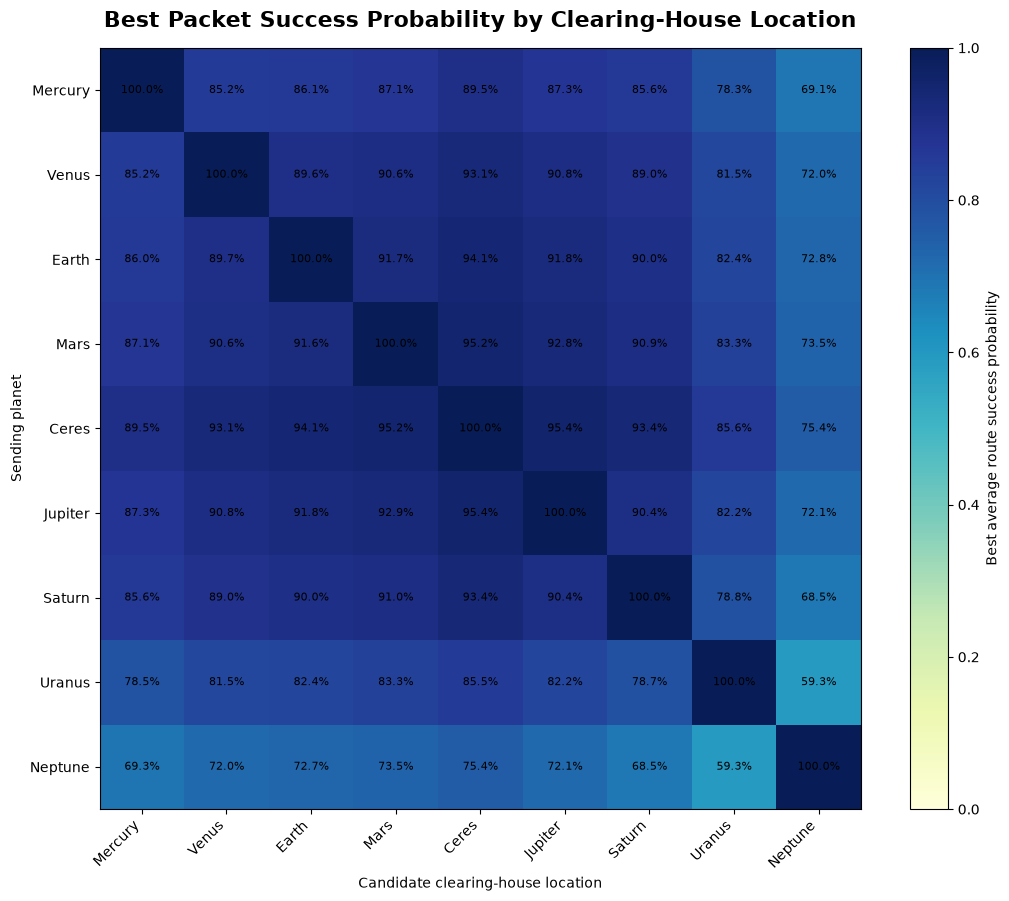

Best route for each source and clearing-house pair:


,Mercury,Venus,Earth,Mars,Ceres,Jupiter,Saturn,Uranus,Neptune
Mercury,direct,via Relay B,via Relay A,via Relay B,via Relay B,via Relay B,via Relay B,via Relay B,via Relay B
Venus,via Relay B,direct,via Relay A,via Relay A,via Relay B,via Relay B,via Relay A,via Relay B,via Relay A
Earth,via Relay B,via Relay A,direct,via Relay A,via Relay B,via Relay A,via Relay A,via Relay B,via Relay A
Mars,via Relay B,via Relay A,via Relay A,direct,via Relay B,via Relay A,via Relay A,via Relay B,via Relay A
Ceres,via Relay B,via Relay B,via Relay B,via Relay B,direct,via Relay B,via Relay B,via Relay B,via Relay B
Jupiter,via Relay B,via Relay A,via Relay A,via Relay A,via Relay B,direct,via Relay B,via Relay B,via Relay A
Saturn,via Relay B,via Relay A,via Relay A,via Relay A,via Relay B,via Relay B,direct,via Relay B,via Relay A
Uranus,via Relay B,via Relay B,via Relay B,via Relay B,via Relay B,via Relay B,via Relay B,direct,via Relay B
Neptune,via Relay B,via Relay A,via Relay A,via Relay A,via Relay B,via Relay A,via Relay A,via Relay B,direct


In [42]:
route_names = list(probability_matrices)
route_arrays = np.stack([
    probability_matrices[route_name].to_numpy()
    for route_name in route_names
])
best_route_indices = route_arrays.argmax(axis=0)
best_probability_matrix = route_arrays.max(axis=0)
best_route_matrix = np.vectorize(route_names.__getitem__)(best_route_indices)

best_probability_dataframe = pd.DataFrame(
    best_probability_matrix,
    index=SETTLEMENTS,
    columns=SETTLEMENTS,
)
best_route_dataframe = pd.DataFrame(
    best_route_matrix,
    index=SETTLEMENTS,
    columns=SETTLEMENTS,
)

fig, ax = plt.subplots(figsize=(11, 9))
heatmap = ax.imshow(
    best_probability_matrix,
    cmap="YlGnBu",
    vmin=0.0,
    vmax=1.0,
    aspect="equal",
)
fig.colorbar(heatmap, ax=ax, label="Best average route success probability")

ax.set_xticks(np.arange(len(SETTLEMENTS)))
ax.set_yticks(np.arange(len(SETTLEMENTS)))
ax.set_xticklabels(SETTLEMENTS, rotation=45, ha="right")
ax.set_yticklabels(SETTLEMENTS)
ax.set_xlabel("Candidate clearing-house location")
ax.set_ylabel("Sending planet")
ax.set_title(
    "Best Packet Success Probability by Clearing-House Location",
    fontsize=16,
    weight="bold",
    pad=15,
)

for source_index in range(len(SETTLEMENTS)):
    for clearing_house_index in range(len(SETTLEMENTS)):
        probability = best_probability_matrix[source_index, clearing_house_index]
        ax.text(
            clearing_house_index,
            source_index,
            f"{probability:.1%}",
            ha="center",
            va="center",
            color="white" if probability < 0.55 else "black",
            fontsize=8,
        )

plt.tight_layout()
plt.show()

print("Best route for each source and clearing-house pair:")
best_route_dataframe

In [43]:
def rank_clearing_houses(probability_matrix):
    """Rank candidates using equally weighted average squared success probability."""
    scores = []
    for candidate in probability_matrix.columns:
        source_probabilities = probability_matrix[candidate].drop(index=candidate)
        limiting_source = source_probabilities.idxmin()
        scores.append({
            "clearing_house": candidate,
            "average_squared_success_probability": np.mean(source_probabilities.to_numpy() ** 2),
            "average_success_probability": source_probabilities.mean(),
            "worst_case_success_probability": source_probabilities.min(),
            "limiting_source": limiting_source,
            "best_case_success_probability": source_probabilities.max(),
        })

    return (
        pd.DataFrame(scores)
        .sort_values(
            ["average_squared_success_probability", "worst_case_success_probability"],
            ascending=False,
        )
        .reset_index(drop=True)
    )

clearing_house_ranking = rank_clearing_houses(probability_matrix)
clearing_house_ranking

,clearing_house,average_squared_success_probability,average_success_probability,worst_case_success_probability,limiting_source,best_case_success_probability
0,Ceres,0.817794,0.902066,0.754386,Neptune,0.954003
1,Mars,0.781266,0.881510,0.735359,Neptune,0.951627
2,Jupiter,0.776727,0.878531,0.721193,Neptune,0.954003
3,Earth,0.766247,0.872955,0.727364,Neptune,0.940906
4,Venus,0.752126,0.864859,0.719877,Neptune,0.930760
5,Saturn,0.742720,0.858297,0.684894,Neptune,0.934425
6,Mercury,0.702164,0.835691,0.693444,Neptune,0.895021
7,Uranus,0.628911,0.789266,0.593179,Neptune,0.855601
8,Neptune,0.496937,0.703393,0.593179,Uranus,0.754386
